[2026-07-13 13:34:54] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-13 13:34:57] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-13 13:34:57] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-13 13:35:02] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-07-13 13:35:02] [info     ] ========== 数据检查 ==========
[2026-07-13 13:35:02] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg_ttm', 'roa_avg_ttm', 'gross_profit_rate_ttm', 'net_profit_rate_ttm', 'debt_to_asset_lf', 'current_ratio_lf', 'netflow_amount_main', 'netflow_amount_rate_main', 'net_act

时段,IC
2024-01-15~2024-02-08,0.0371
2024-09-24~2024-10-08,0.0045

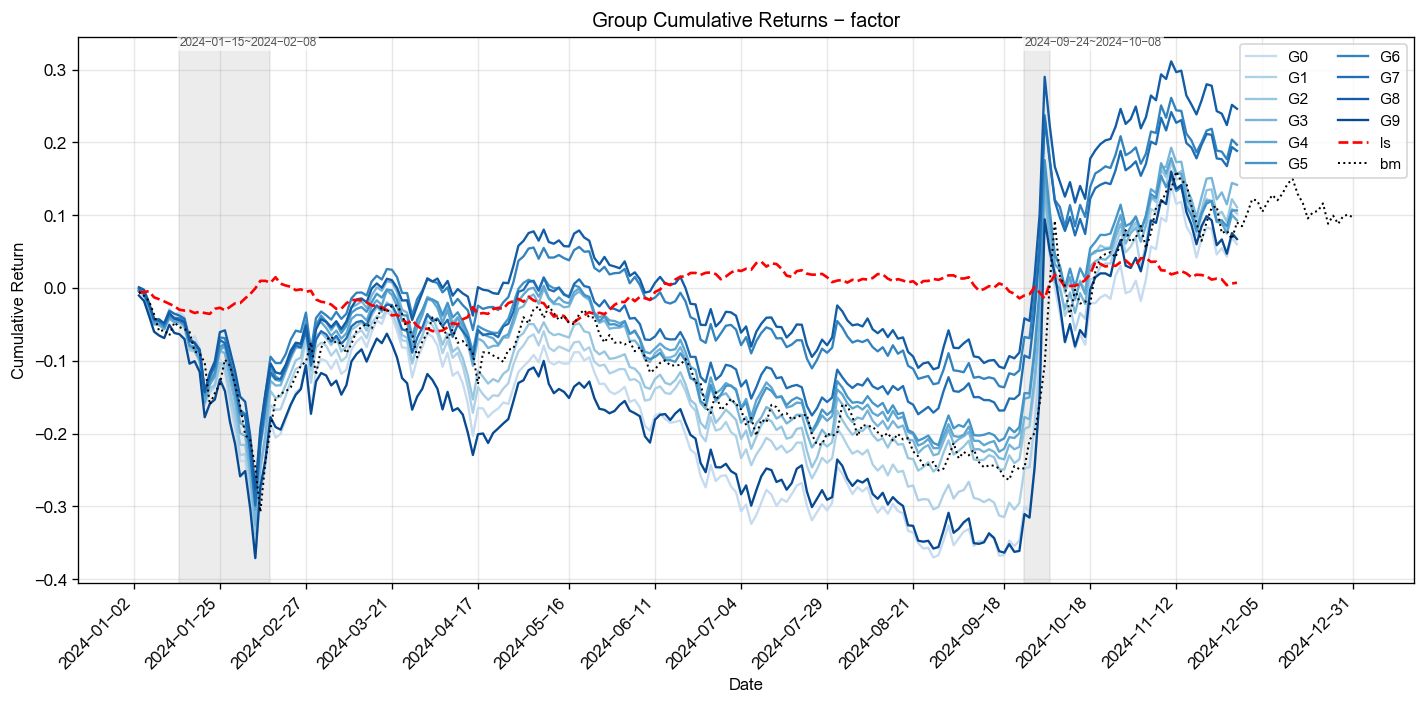
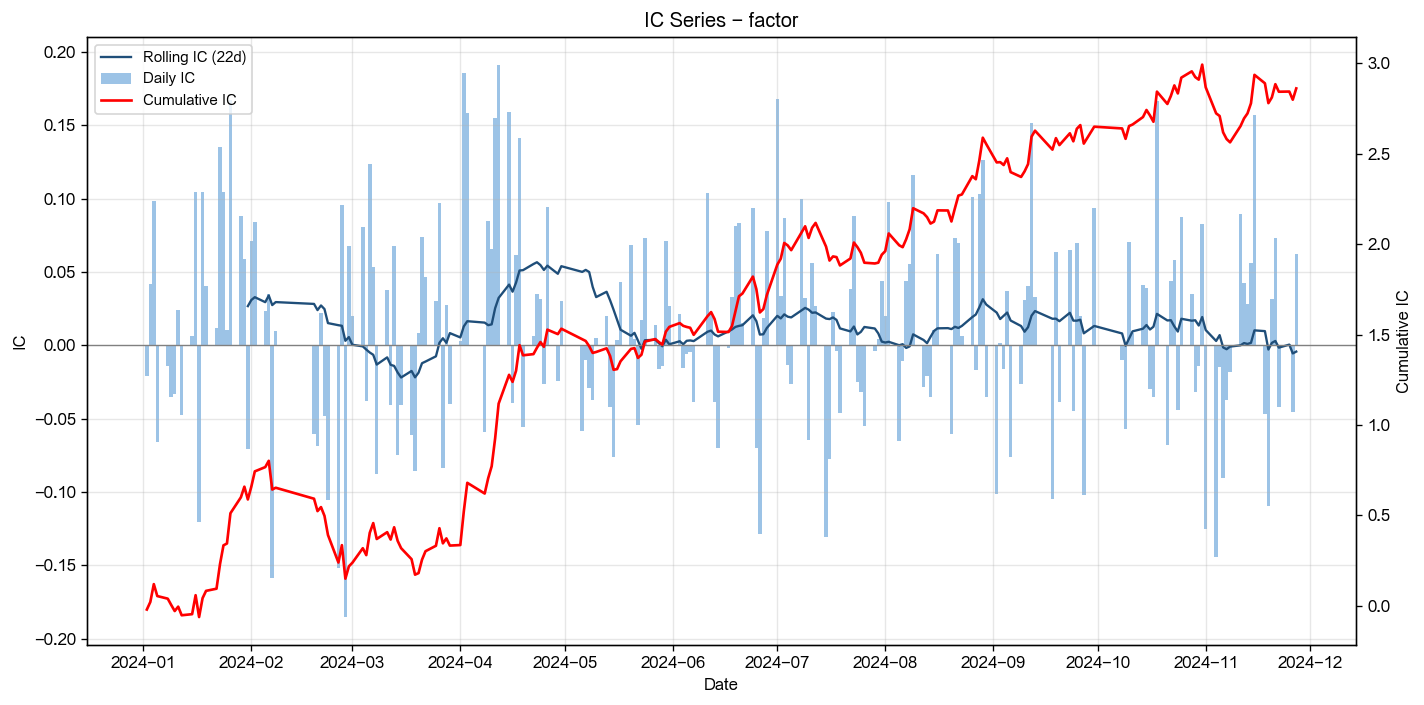
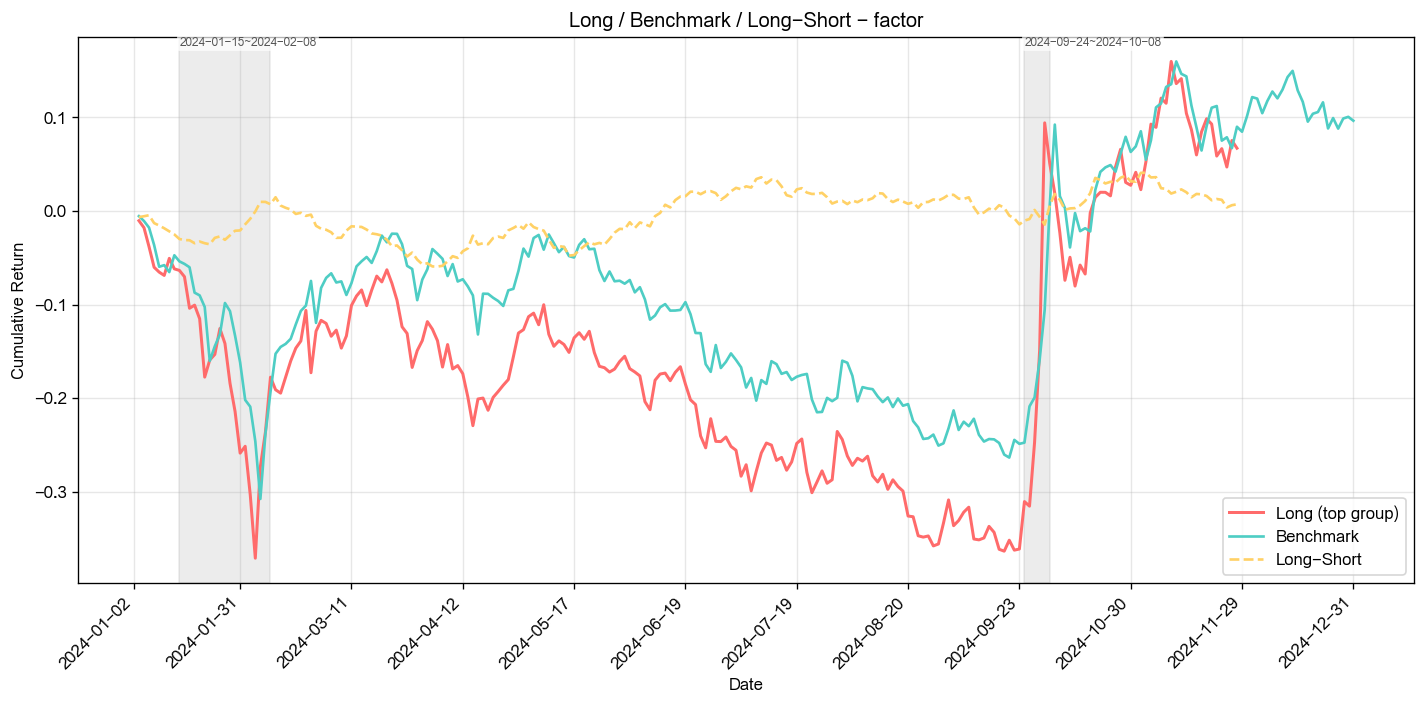
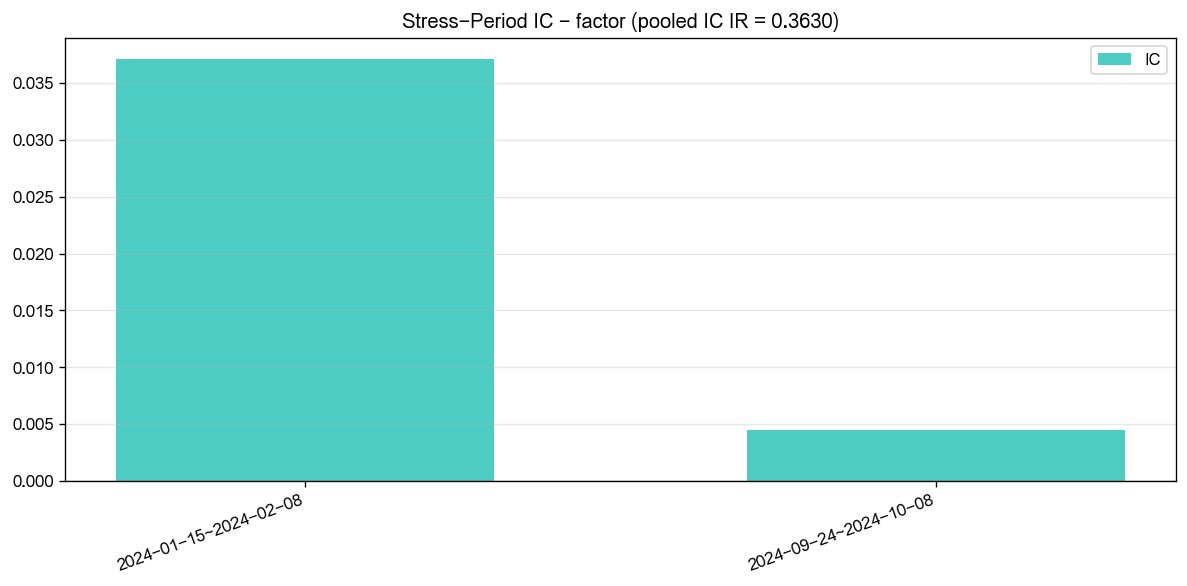
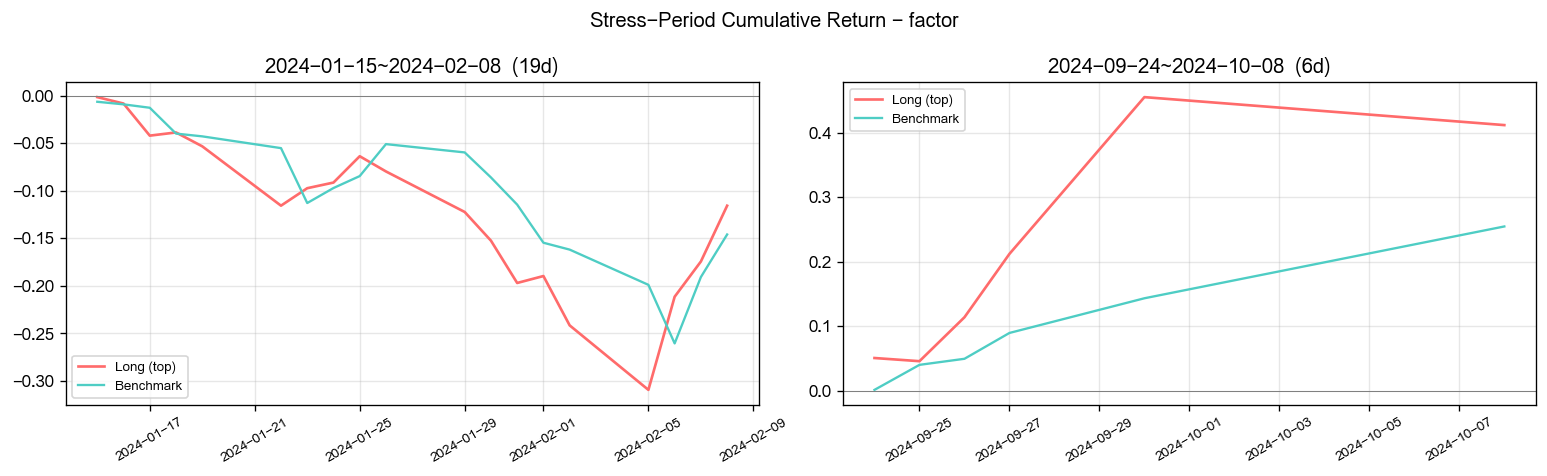

[2026-07-13 13:36:31] [info     ] ========== 因子池回归 ==========
[2026-07-13 13:36:32] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-13 13:36:36] [info     ] 获取收益率数据, 耗时: 4.7843 秒
[2026-07-13 13:36:38] [info     ] 滚动 Elastic Net 拟合, 耗时: 1.4194 秒
[2026-07-13 13:36:38] [info     ] 统计 回归结果, 耗时: 0.0074 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.9363,0.0446,0.0230,1.0000
2,amount,1.7304,0.0185,0.0107,0.9000
3,netflow_amount_rate_main,1.6309,0.0101,0.0062,1.0000
4,netflow_amount_main,1.5156,0.0251,0.0166,1.0000
5,gross_profit_rate_ttm,1.5074,0.0069,0.0046,1.0000
6,net_profit_rate_ttm,1.4412,0.0040,0.0028,0.8000
7,pb,1.4169,0.0097,0.0068,1.0000
8,bias_20,1.4104,0.0291,0.0207,0.9000
9,cci_14,1.3853,0.0338,0.0244,1.0000
10,pe_ttm,1.3020,0.0029,0.0022,0.9000

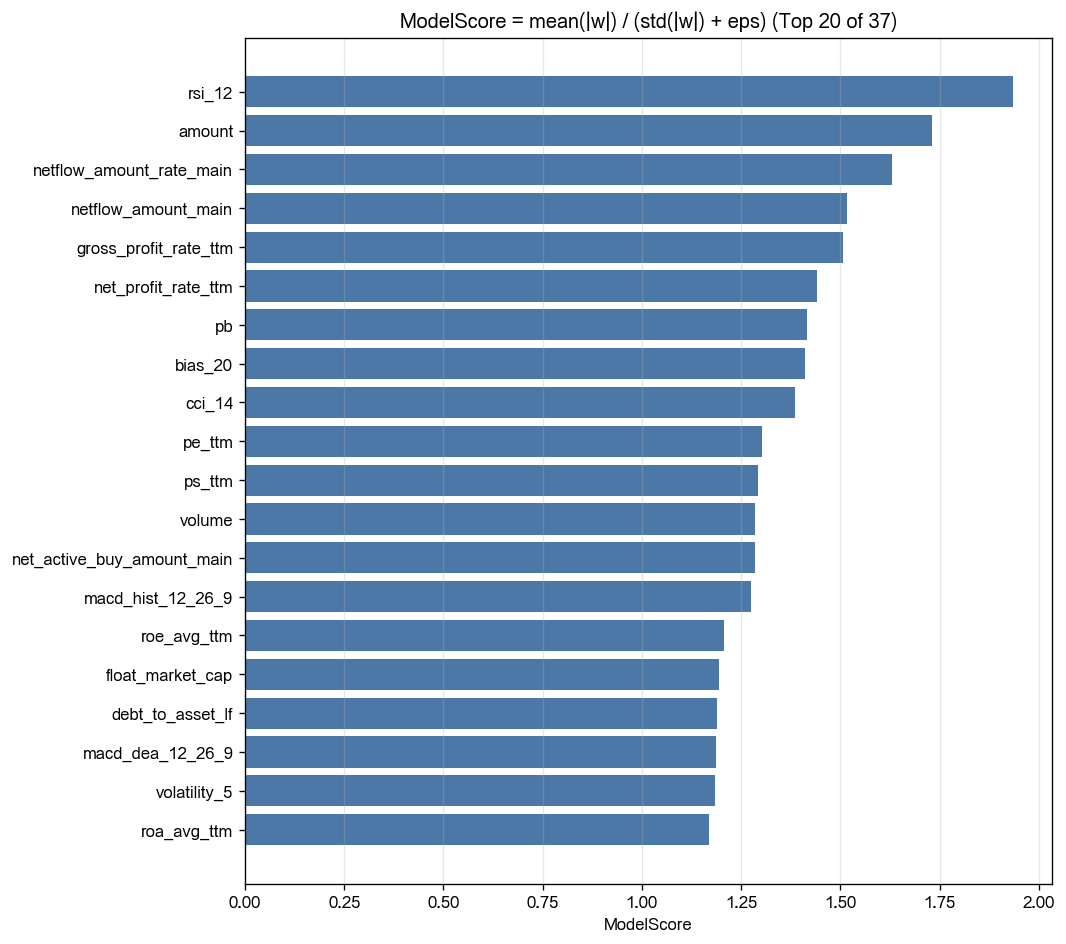
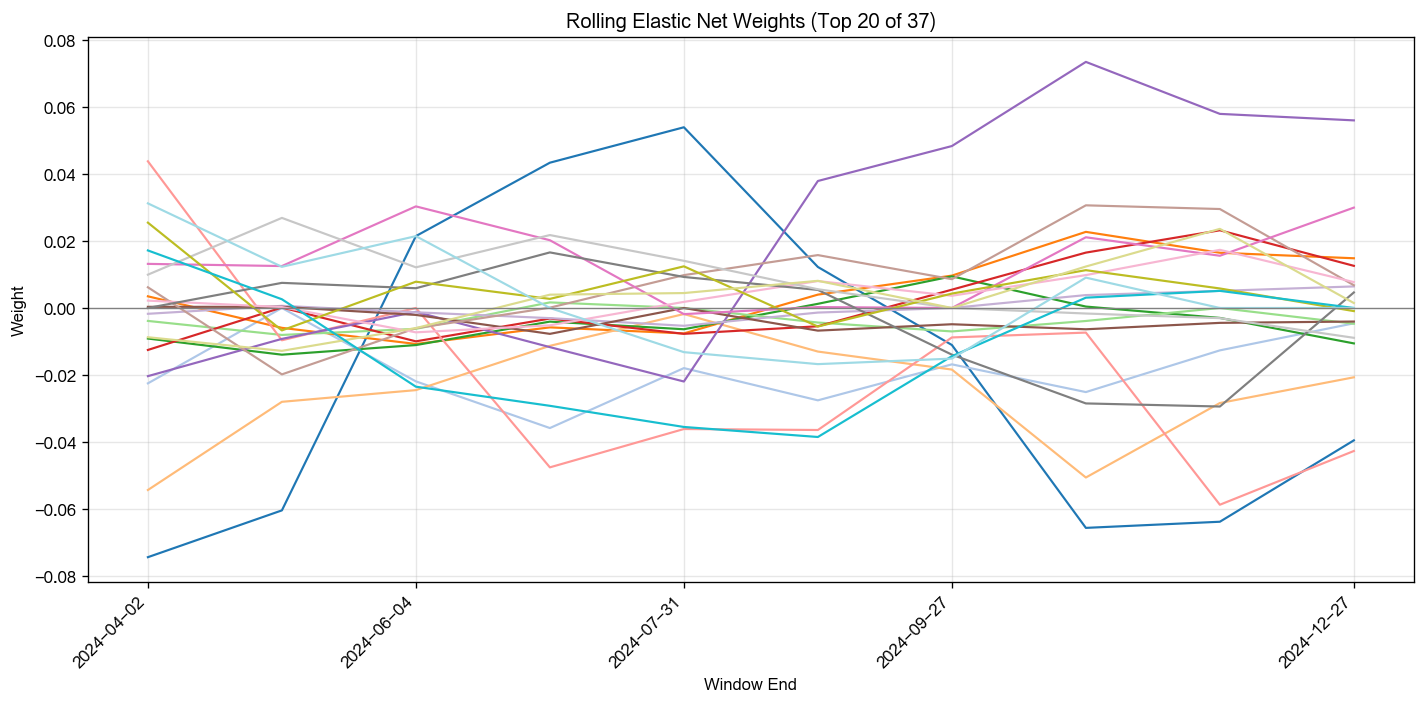
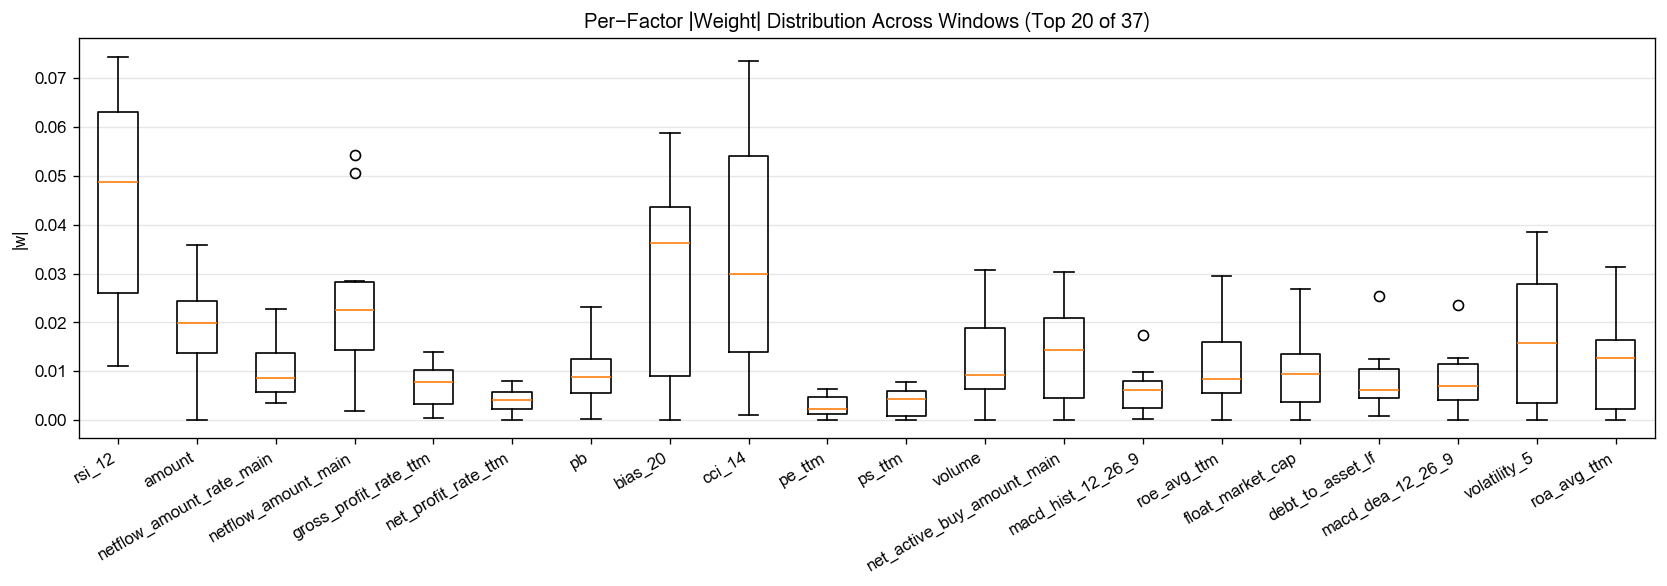
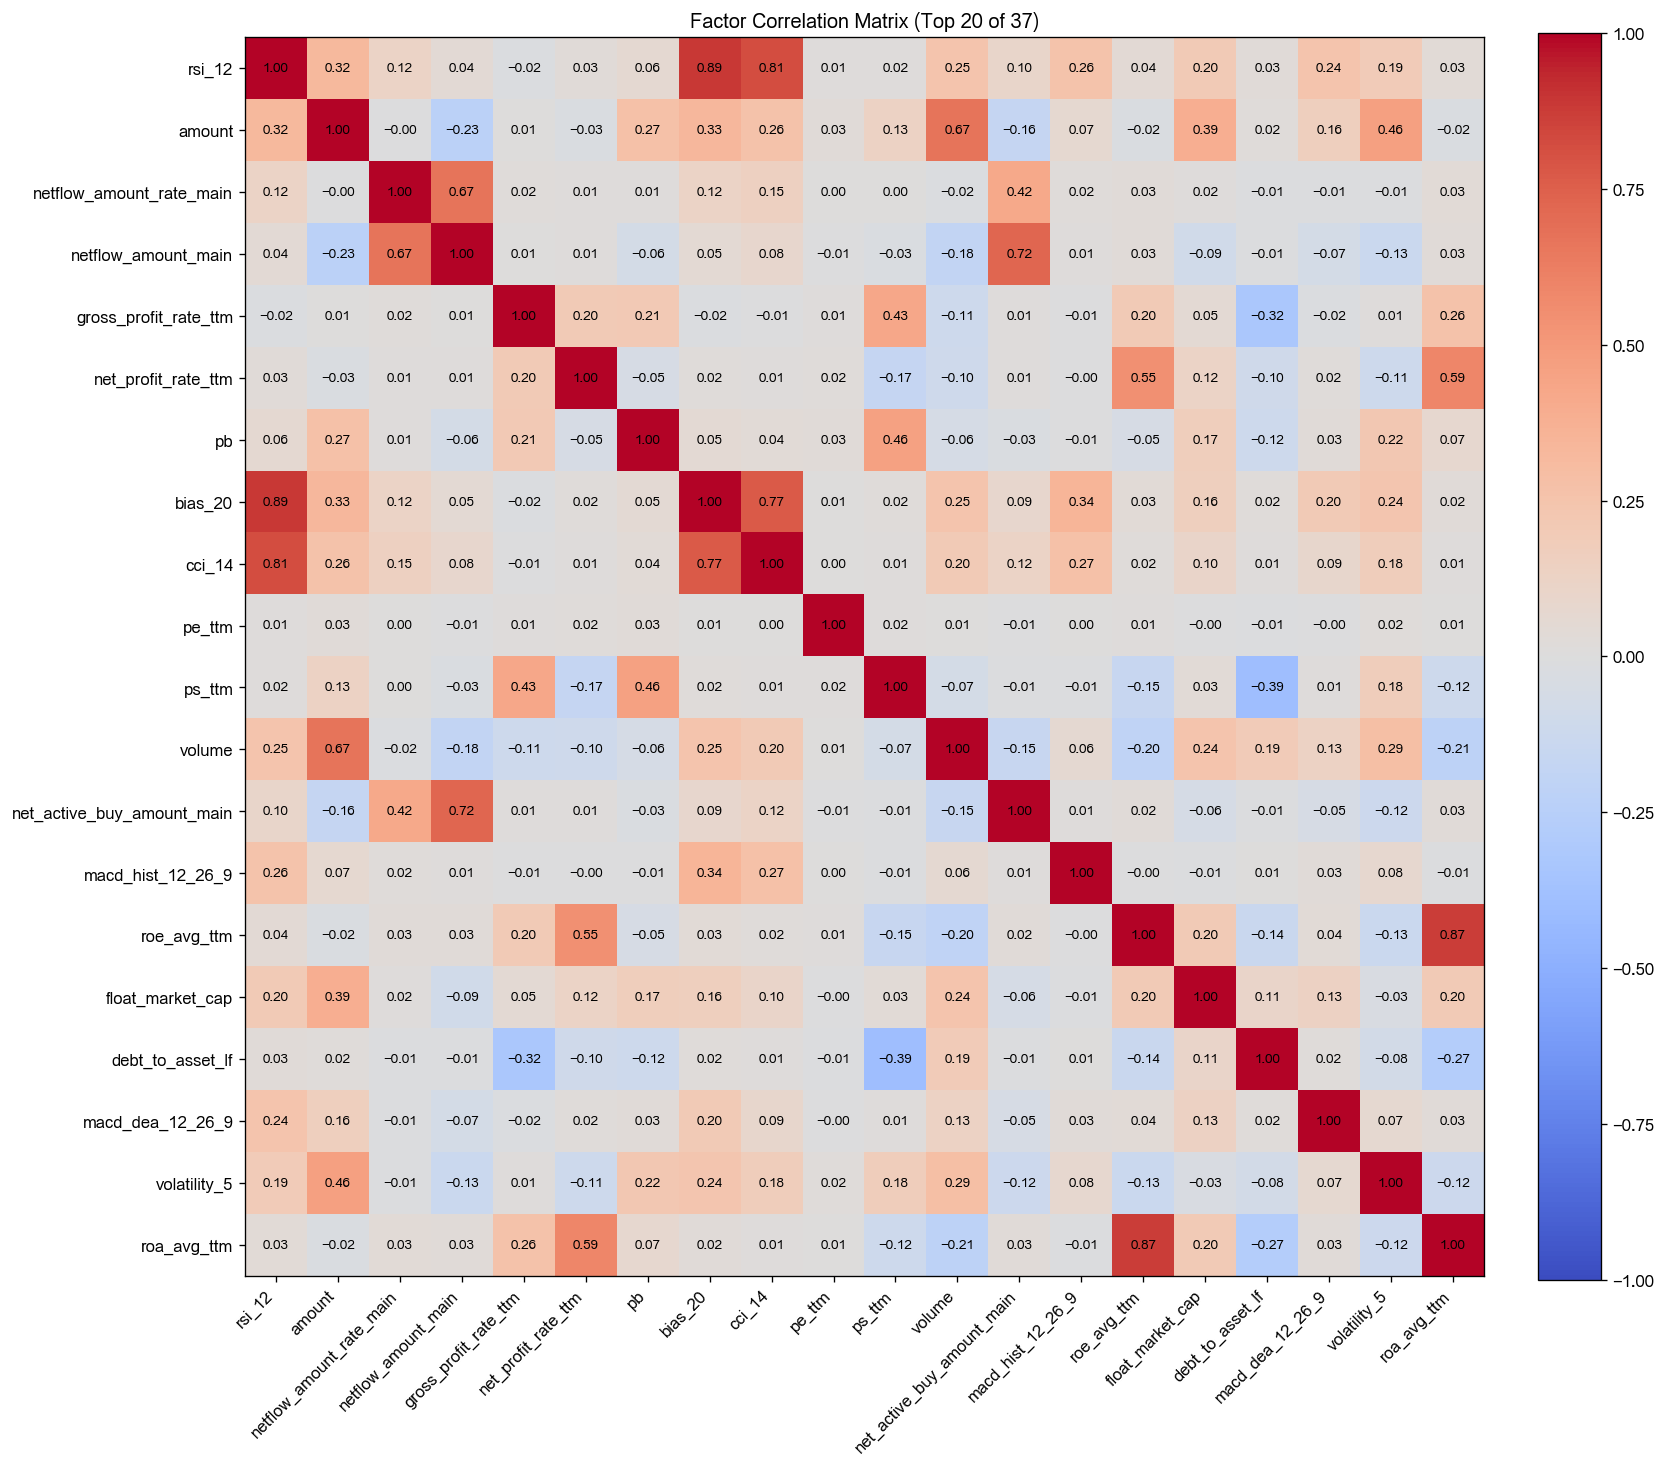

[2026-07-13 13:36:40] [warning  ] 返回的Outputs实例(size=32777176) 大于 64K, 将不会被缓存
[2026-07-13 13:36:40] [info     ] bigalpha_eval.v4 运行完成 [103.353s].


In [3]:
def main(datasources, start_date, end_date):
    """
    ATS × 买卖盘压力 × ATS稳定性 因子

    返回列必须为:
    ['date', 'instrument', 'factor']
    """
    import pandas as pd
    import dai

    bar1m = datasources["bar1m"]

    sql = f"""
    WITH minute_raw AS (
        SELECT
            date,
            CAST(strftime(date, '%Y-%m-%d') AS DATETIME) AS trading_day,
            instrument,
            volume,
            amount,

            COALESCE(bid_volume1, 0) +
            COALESCE(bid_volume2, 0) +
            COALESCE(bid_volume3, 0) +
            COALESCE(bid_volume4, 0) +
            COALESCE(bid_volume5, 0) AS bid_volume,

            COALESCE(ask_volume1, 0) +
            COALESCE(ask_volume2, 0) +
            COALESCE(ask_volume3, 0) +
            COALESCE(ask_volume4, 0) +
            COALESCE(ask_volume5, 0) AS ask_volume,

            CAST(strftime(date, '%H%M%S') AS INT) AS hhmmss
        FROM {bar1m}
        WHERE date >= CAST('{start_date}' AS DATETIME)
        AND date <= CAST('{end_date}' AS DATETIME)
        AND volume >= 0
        AND amount >= 0
        AND (
                CAST(strftime(date, '%H%M%S') AS INT) BETWEEN 93100 AND 113000
                OR CAST(strftime(date, '%H%M%S') AS INT) BETWEEN 130100 AND 150000
            )
    ),

    minute_diff AS (
        SELECT
            *,
            lag(volume, 1) OVER (
                PARTITION BY instrument, trading_day
                ORDER BY date
            ) AS prev_volume,

            lag(amount, 1) OVER (
                PARTITION BY instrument, trading_day
                ORDER BY date
            ) AS prev_amount
        FROM minute_raw
    ),

    minute_feature AS (
        SELECT
            date,
            trading_day,
            instrument,

            CASE
                WHEN prev_volume IS NULL THEN 0
                WHEN volume >= prev_volume THEN volume - prev_volume
                ELSE 0
            END AS minute_volume,

            CASE
                WHEN prev_amount IS NULL THEN 0
                WHEN amount >= prev_amount THEN amount - prev_amount
                ELSE 0
            END AS minute_amount,

            CASE
                WHEN bid_volume + ask_volume > 0
                THEN (bid_volume - ask_volume) / (bid_volume + ask_volume + 1e-8)
                ELSE 0
            END AS order_imbalance
        FROM minute_diff
    ),

    minute_ats AS (
        SELECT
            m.trading_day,
            m.instrument,

            CASE
                WHEN m.minute_volume > 0
                AND v.float_market_cap > 0
                THEN (m.minute_amount / m.minute_volume) / v.float_market_cap
                ELSE 0
            END AS ats,

            m.order_imbalance
        FROM minute_feature m
        INNER JOIN cn_stock_valuation v
            ON m.trading_day = CAST(strftime(v.date, '%Y-%m-%d') AS DATETIME)
            AND m.instrument = v.instrument
        WHERE v.float_market_cap > 0
    ),

    daily_factor AS (
        SELECT
            trading_day,
            instrument,

            avg(ats) AS ats_mean,
            nanstd(ats) AS ats_std,
            avg(order_imbalance) AS oi_mean,
            count(*) AS minute_count
        FROM minute_ats
        GROUP BY trading_day, instrument
    )

    SELECT
        trading_day AS date,
        instrument,

        ats_mean
        * oi_mean
        * (ats_mean / (COALESCE(ats_std, 0) + 1e-8)) AS factor

    FROM daily_factor
    WHERE minute_count >= 60
    AND ats_mean IS NOT NULL
    AND oi_mean IS NOT NULL
    """

    df = dai.query(
        sql,
        filters={"date": [start_date, end_date]},
        compression=True,
    ).df()

    if df.empty:
        return pd.DataFrame(columns=["date", "instrument", "factor"])

    df["date"] = pd.to_datetime(df["date"]).dt.normalize()
    df = df.replace([float("inf"), float("-inf")], pd.NA)
    df = df.dropna(subset=["factor"])
    df = df[["date", "instrument", "factor"]]

    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={"date": [start_date, end_date]},
    ).df()

    stk_pool["date"] = pd.to_datetime(stk_pool["date"]).dt.normalize()

    df = pd.merge(df, stk_pool, how="inner", on=["date", "instrument"])

    return df

if __name__ == "__main__":
    from bigmodule import M
    import dai

    datasources = {"bar1m": "bigalpha_2026_stock_bar1m"}
    start_date = "2024-01-01 00:00:00"
    end_date = "2024-12-31 23:59:59"

    factor_data = main(datasources, start_date, end_date)

    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={"date": [start_date, end_date]},
    ).df()

    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )